# Value Iteration
In this notebook, you are going to implement a value-based approach for solving a MDP, called *Value Iteration*.

The total points of **_Value Iteration_** implementation is **30 POINTS**.

## Import the necessary software libraries:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from gridworld import Environment
from utils import plot_policy, plot_values, test_agent

pygame 2.5.2 (SDL 2.28.3, Python 3.11.4)
Hello from the pygame community. https://www.pygame.org/contribute.html


## Initialize the environment

In [2]:
env = Environment()
state = env.reset()

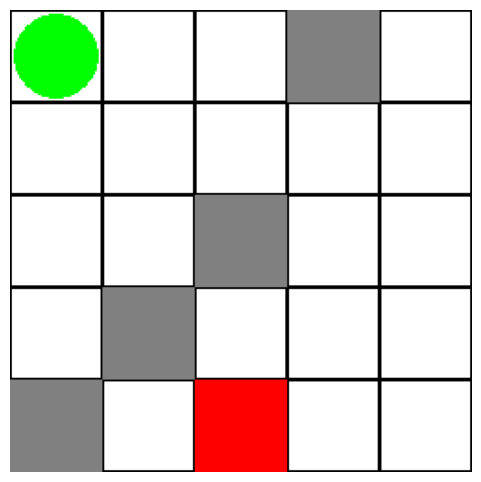

In [3]:
frame = env.render()
plt.figure(figsize=(6,6))
plt.axis('off')
plt.imshow(frame)

In [4]:
print(f"Observation space shape: {env.observation_space.nvec}")
print(f"Number of actions: {env.action_space.n}")

Observation space shape: [5 5]
Number of actions: 4


## Define the policy $\pi(\cdot|s)$

#### Create the policy $\pi(\cdot|s)$

In [5]:
policy_probs = np.full((env.GH, env.GW, 4), 0.25)

In [6]:
def policy(state):
    return policy_probs[state]

#### Test the policy with state (0, 0)

In [7]:
action_probabilities = policy((0,0))
for action, prob in zip(range(4), action_probabilities):
    print(f"Probability of taking action {action}: {prob}")

Probability of taking action 0: 0.25
Probability of taking action 1: 0.25
Probability of taking action 2: 0.25
Probability of taking action 3: 0.25


#### See how the random policy does in the maze

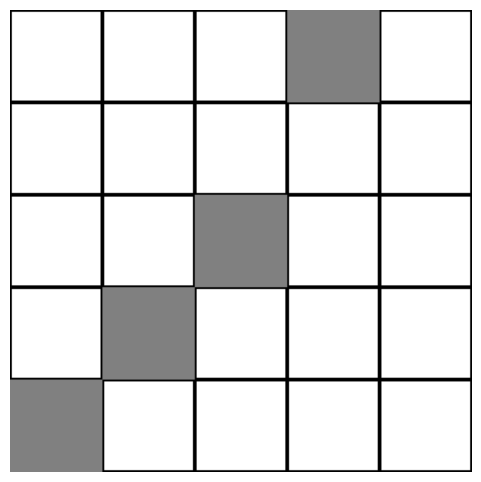

In [8]:
test_agent(env, policy, episodes=1)

#### Plot the policy

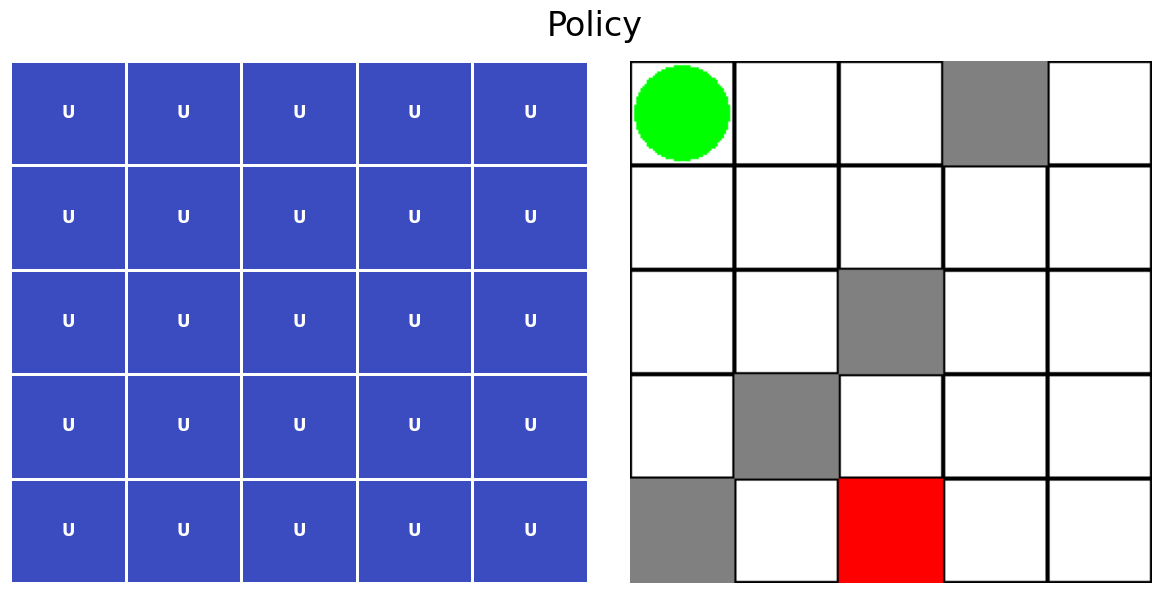

In [9]:
plot_policy(policy_probs, frame)

## Define value table $V(s)$

#### Create the $V(s)$ table

In [10]:
state_values = np.zeros(shape=(env.GH,env.GW))
print(state_values)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


#### Plot $V(s)$

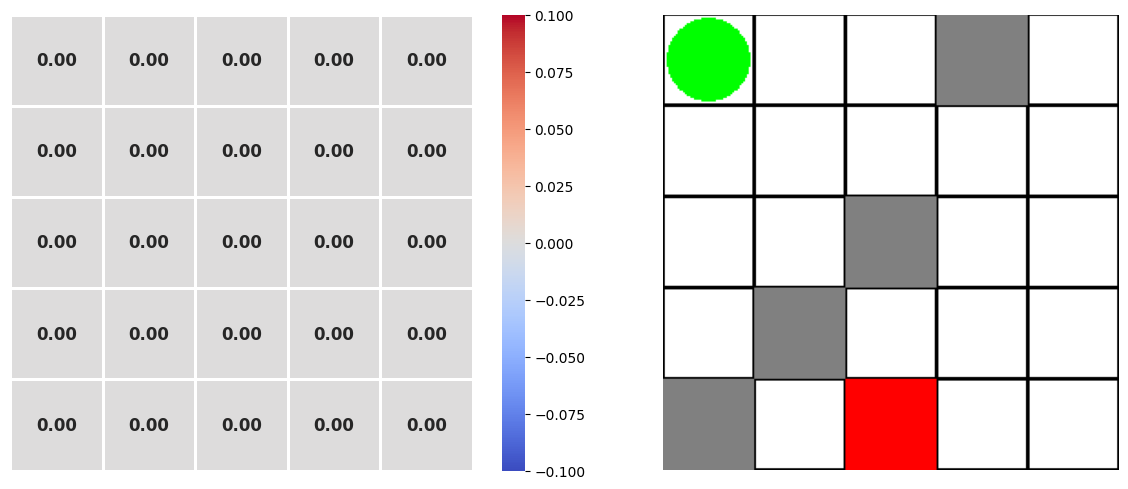

In [11]:
plot_values(state_values, frame)

## Implement the Value Iteration algorithm
<a target="_parent">
    <img src="value-iteration.png" width="50%"/>
</a> 
<!-- ![Value iteration algorithm](value-iteration.png) -->



#### Insert your code here to implement the Value Iteration algorithm.

In [12]:
policy_probs = np.full((env.GH, env.GW, 4), 0.25)
state_values = np.zeros(shape=(env.GH,env.GW))
def value_iteration(policy_probs, state_values, theta=1e-6, gamma=0.9):
    # TODO: You need to implement the Value Iteration algorithm here.
    
    iteration_count=0
    
    #Explaining how the random policy above works:
        #From the environment: {0: 'UP', 1: 'RIGHT', 2: 'DOWN', 3: "LEFT"}
        #policy(state) returns the value for an action at the state in policy_probs which is one of the things set in this method
        #policy_probs seems to be 4 different grid sized arrays that correspond to the desireablility of each action
        #state_values seems to be the max of each of the 4 grids
    
    #Perform a while loop until the break condition is met    
    while True:
        iteration_count+=1
        
        #(re)set Vp
        Vp=np.zeros(shape=(env.GH,env.GW))
        
        
         
        #go through every cells values for states and policies
        #print(policy_probs.shape)
        #print(Vp.shape)
            
        for row in range(env.GH):
            for col in range(env.GW):
                #Check each action to update the policy for the action if valid
                if env.noCollision(col,row):
                    for act in range(env.ACTIONS):
                        
                        #get outputs from simulated step
                        test_state, test_reward, test_terminal, test_info = env.simulate_step((row,col),act)
                        
                        if test_terminal:
                            Vsp=0
                        else:
                            #if not at the goal, find V(s') = Vsp
                            Vsp=state_values[test_state]
                            
                        #Use the policy probs to store the action values
                        policy_probs[(row,col,act)]=1*(test_reward+gamma*Vsp)
                        #print("row: ",row,"; col: ", col,"; act: ",act,"; pol_prob:", policy_probs[(row,col,act)])
                        
                    #assign the max state value to the V'(s)
                    Vp[row,col]=np.max(policy_probs[row,col,:])
        
        #print("policy probs are: ")
        #print(policy_probs)
        
        #Create break condtion
        if np.max(np.abs(Vp-state_values)) <=theta:
            print("iteration count is:")
            print(iteration_count)
            print("NonFloored policy_probs are:")
            print(policy_probs)
            #print("final state_values are:")
            #print(state_values)
            
            #Now that the state values have been set, set the first "best" direction to be the policy
            for row in range(env.GH):
                for col in range(env.GW):
                    row_max=np.max(policy_probs[row,col,:])
                    
                    max_set=False
                    
                    for act in range(env.ACTIONS):
                        if policy_probs[row,col,act]==row_max and not max_set:
                            policy_probs[row,col,act]=1
                            max_set=True
                        else:
                            policy_probs[row,col,act]=0
                    #update state_values without changing the reference
            state_values[:]=Vp   
            print("Final State Values:")
            print(state_values)
            print("Final policy is:")
            print(policy_probs)
            break
        else:
            #print("iteration count is:")
            #print(iteration_count)
            #print("Vprime is")
            #print(Vp)
            
            #update state_values without changing the reference
            state_values[:]=Vp
            
            #print("iteration count is:")
            #print(iteration_count)
            #print("state values are:")
            #print(state_values)
        
        
    
    # TODO: Add comments to explain your code
    
    return

Questions:

1. Did I set the policy correctly?

In [13]:
env = Environment()
state = env.reset()
state_values = np.zeros(shape=(env.GH,env.GW))
print("Policy probs before:")
print(policy_probs)
value_iteration(policy_probs, state_values)
print("Policy probs before:")
print(policy_probs)


Policy probs before:
[[[0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]]

 [[0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]]

 [[0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]]

 [[0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]]

 [[0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]
  [0.25 0.25 0.25 0.25]]]
iteration count is:
11
NonFloored policy_probs are:
[[[0.38742049 0.43046721 0.43046721 0.38742049]
  [0.43046721 0.4782969  0.4782969  0.38742049]
  [0.4782969  0.4782969  0.531441   0.43046721]
  [0.25       0.25       0.25       0.25      ]
  [0.4782969  0.4782969  0.531441   0.4782969 ]]

 [[0.38742049 0.4782969  0.38742049 0.43046721]
  [0.43046721 0.531441   0.

## Show results

#### Show resulting value table $V(s)$

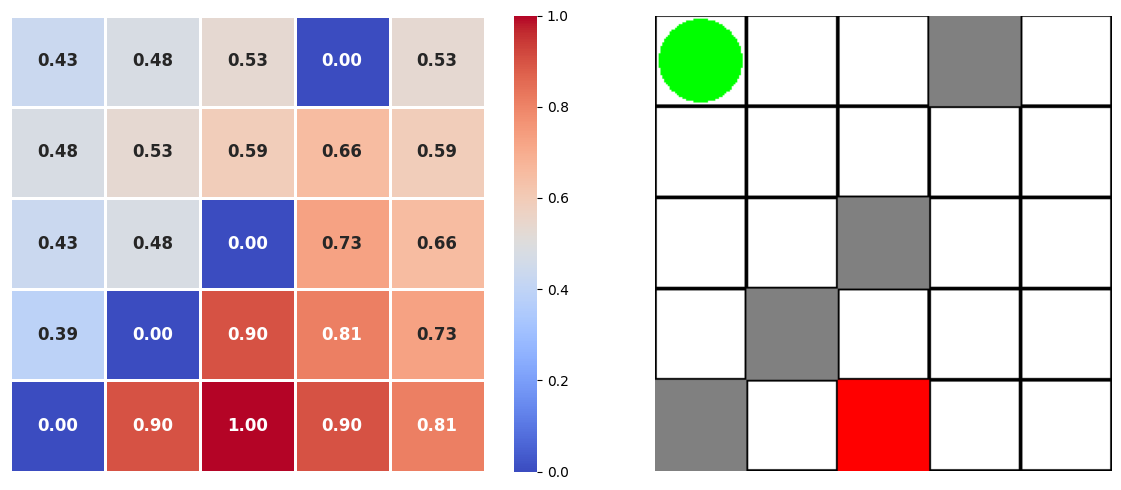

In [14]:
plot_values(state_values, frame)

#### Show resulting policy $\pi(\cdot|s)$

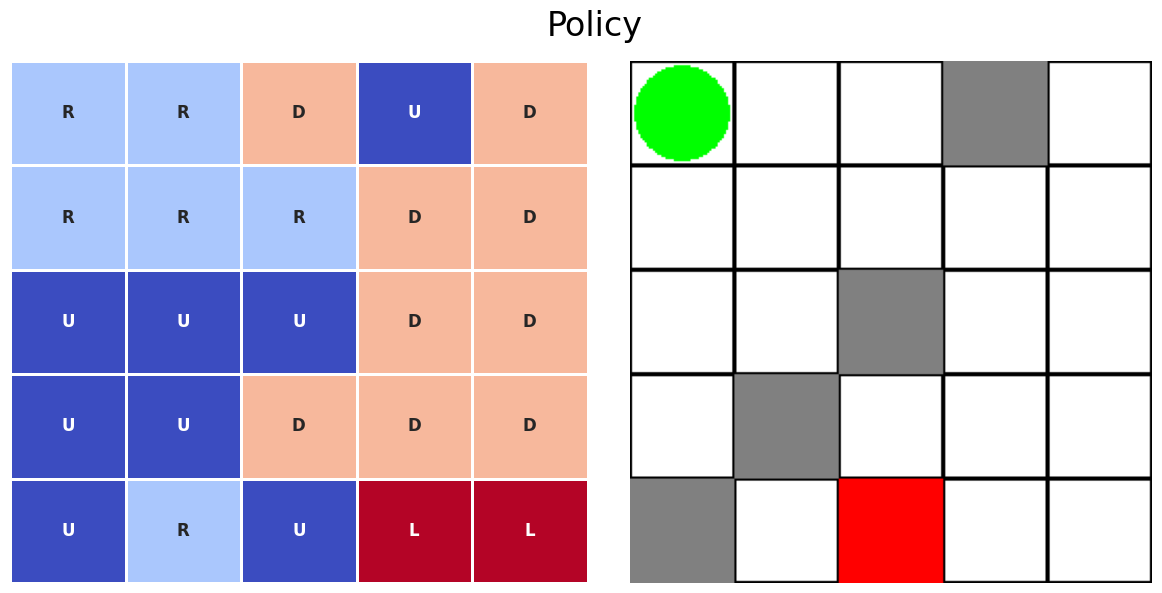

In [15]:
plot_policy(policy_probs, frame)

#### Test the resulting agent

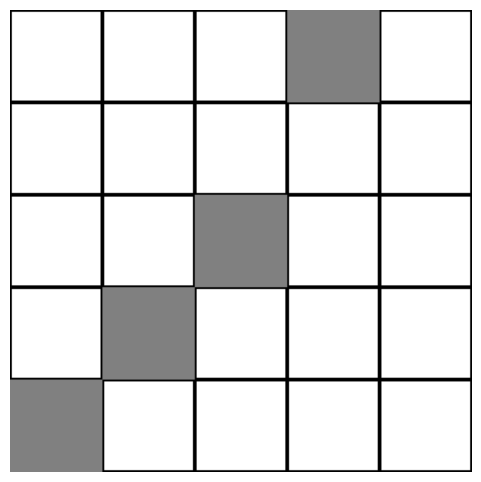

In [16]:
test_agent(env, policy, episodes=1)